## Universidade Federal do Rio de Janeiro
### Introdução a Aprendizado de Máquina
### João Pedro Duarte Baptista
### 121066907

Objetivo: identificar, dentre os clientes que solicitam um produto de crédito (como um cartão de crédito ou um empréstimo pessoal, por exemplo) e que cumprem os pré-requisitos essenciais para a aprovação do crédito, aqueles que apresentem alto risco de não conseguirem honrar o pagamento, tornando-se inadimplentes.

Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
import urllib.parse

from google.colab import files
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.exceptions import DataConversionWarning
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
warnings.filterwarnings(action='ignore', category=DataConversionWarning)
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

from xgboost import XGBClassifier

pd.options.display.max_columns = 999

raw_url_teste = 'https://raw.githubusercontent.com/jpdb0605/engenharia_eletronica/refs/heads/main/Introdução a Aprendizado de Máquina/Classificação/conjunto_de_teste.csv'
raw_url_treino = 'https://raw.githubusercontent.com/jpdb0605/engenharia_eletronica/refs/heads/main/Introdução a Aprendizado de Máquina/Classificação/conjunto_de_treinamento.csv'

url_teste = urllib.parse.quote(raw_url_teste, safe=':/')
url_treino = urllib.parse.quote(raw_url_treino, safe=':/')

df_training = pd.read_csv(url_treino)
df_teste = pd.read_csv(url_teste)

Pre-Processing

In [2]:
# Primeiro sera feito o pre processamento das variaveis
# Comecando pelas colunas a serem descartadas
# As colunas foram descartadas por recomendacao do dicionario de dados ou por terem informacoes
# redundantes e irrelevantes
colunas_drop = ['possui_cartao_amex','possui_telefone_celular','codigo_area_telefone_trabalho','qtde_contas_bancarias_especiais', 'id_solicitante','codigo_area_telefone_residencial','grau_instrucao']
colunas_null = ['profissao','ocupacao','profissao_companheiro','grau_instrucao_companheiro']
colunas_para_string = ['profissao','ocupacao','profissao_companheiro', 'produto_solicitado', 'dia_vencimento','tipo_endereco','estado_civil','nacionalidade']
colunas_estado = ['estado_onde_nasceu', 'estado_onde_reside', 'estado_onde_trabalha']
colunas_numericas = ['idade', 'meses_na_residencia','meses_no_trabalho', 'renda_mensal_regular', 'renda_extra', 'valor_patrimonio_pessoal']
colunas_quantidades = ['qtde_dependentes', 'qtde_contas_bancarias']
colunas_YN = ['possui_telefone_residencial', 'vinculo_formal_com_empresa','possui_telefone_trabalho']
colunas_categorias = ['forma_envio_solicitacao', 'tipo_residencia', 'sexo','possui_email','possui_cartao_visa', 'possui_cartao_mastercard', 'possui_cartao_diners',
     'possui_outros_cartoes', 'possui_carro']
colunas_dummies = colunas_para_string + colunas_categorias

mapa_YN = {'Y':1, 'N':0}

def pre_processing(arquivo):
  arquivo = arquivo.drop(columns=colunas_drop, errors='ignore')



  for coluna in colunas_null:
    # Aqui os valores nulos sao substituidos por -1
    if coluna in arquivo.columns:
      arquivo[coluna] = arquivo[coluna].fillna(-1)

  # Depois sao tratadas as colunas de estado (nascimento, residencia e trabalho)
  # Aqui os estados nulos ou XX sao trocados por uma categoria de n_informado, significando
  # que nao ha informacao sobre essa variavel para aquele solicitante
  for coluna in colunas_estado:
    if coluna in arquivo.columns:
      arquivo[coluna] = arquivo[coluna].fillna('n_informado')
      arquivo[coluna] = arquivo[coluna].replace('XX','n_informado')
      arquivo[coluna] = arquivo[coluna].replace(' ','n_informado')

      # Aqui os estados sao trocados por valores que representam a sua frequencia relativa
      # para determinar melhor a importancia do estado
      frequencias = arquivo[coluna].value_counts(normalize=True)
      arquivo[coluna] = arquivo[coluna].map(frequencias)

  # Aqui as colunas sao trocadas por string para usar como dummies depois
  for coluna in colunas_para_string:
    if coluna in arquivo.columns:
      arquivo[coluna] = arquivo[coluna].astype(str)

  # Aqui as linhas vazias de colunas numericas sao trocadas por medianas
  for coluna in colunas_numericas:
    if coluna in arquivo.columns:
      mediana = arquivo[coluna].median()
      arquivo[coluna] = arquivo[coluna].fillna(mediana)

  # Aqui as linhas vazias de colunas de quantidades sao trocads por zero
  for coluna in colunas_quantidades:
    if coluna in arquivo.columns:
      arquivo[coluna] = arquivo[coluna].fillna(0)

  # Aqui as colunas binarias de Y/N serao trocadas por valores de 1/0
  # Estou assumindo que se a celula for vazia irei trocar por N
  for coluna in colunas_YN:
    if coluna in arquivo.columns:
      arquivo[coluna] = arquivo[coluna].map(mapa_YN)
      arquivo[coluna] = arquivo[coluna].fillna(0).astype(int)

  # Aqui serao tratadas as colunas textuais
  for coluna in colunas_categorias:
    if coluna in arquivo.columns:
      arquivo[coluna] = arquivo[coluna].fillna('N')

  colunas_dummies_existentes = [coluna for coluna in colunas_dummies if coluna in arquivo.columns]
  arquivo = pd.get_dummies(arquivo, columns=colunas_dummies_existentes, drop_first=True, dtype=int)
  return arquivo

df_training = pre_processing(df_training)
df_teste = pre_processing(df_teste)

Training with Random Forst and Gradient Boosting

Gradient Boosting
Acuracia: 0.5930
ROC-AUC:  0.6280

Relatorio de Classificacao:
              precision    recall  f1-score   support

           0       0.60      0.58      0.59      3000
           1       0.59      0.60      0.60      3000

    accuracy                           0.59      6000
   macro avg       0.59      0.59      0.59      6000
weighted avg       0.59      0.59      0.59      6000



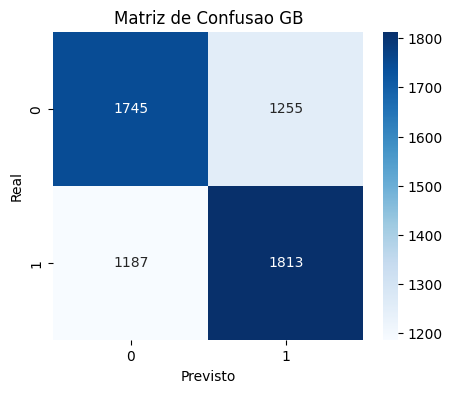

In [3]:
X = df_training.drop(columns=['inadimplente'])
y = df_training['inadimplente']

# Aqui o arquivo de treinamento eh separado em 14000 para treinamento e 6000 para testagem
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Algoritmo Random Forest
#rf = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1)
#rf.fit(X_train, y_train)

#y_pred_rf = rf.predict(X_val)
#y_proba_rf = rf.predict_proba(X_val)[:, 1]
# O algoritmo de gradient boosting deu um resultado melhor em todos os casos
# entao deixarei comentado para nao ficar atrasando o tempo de execucao

# ALgoritmo Gradient Boosting
# o melhor resultado foi com: n_estimators = 1000 learning_rate = 0.05, max_depth = 4
gb = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.05,max_depth=4, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_val)
y_proba_gb = gb.predict_proba(X_val)[:, 1]


# Aqui eh feita uma funcao para comparar e avaliar as metricas de cada modelo
# sendo elas a acuracia e AUC
def avaliar_modelo(nome, y_true, y_pred, y_proba):
    print(f"{nome}")
    print(f"Acuracia: {accuracy_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:  {roc_auc_score(y_true, y_proba):.4f}")
    print("\nRelatorio de Classificacao:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusao GB')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

#avaliar_modelo("Random Forest", y_val, y_pred_rf, y_proba_rf)
avaliar_modelo("Gradient Boosting", y_val, y_pred_gb, y_proba_gb)

Training With XGBoost

In [4]:
# Aqui os parametros foram ajustados e testados diversas vezes e
# a melhor configuracao obtida foi a seguinte:

xgb_model = XGBClassifier(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=10,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    early_stopping_rounds=50)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100)

y_pred_val = xgb_model.predict(X_val)
y_proba_val = xgb_model.predict_proba(X_val)[:, 1]

print("\nResultados XGBoost")
print(f"Melhor Iteracao: {xgb_model.best_iteration}")
print(f"ROC-AUC na Validacao: {roc_auc_score(y_val, y_proba_val):.4f}")
print(classification_report(y_val, y_pred_val))

[0]	validation_0-auc:0.56807
[100]	validation_0-auc:0.63126
[200]	validation_0-auc:0.63787
[300]	validation_0-auc:0.63986
[400]	validation_0-auc:0.64023
[500]	validation_0-auc:0.64167
[555]	validation_0-auc:0.64102

Resultados XGBoost
Melhor Iteracao: 505
ROC-AUC na Validacao: 0.6418
              precision    recall  f1-score   support

           0       0.61      0.58      0.59      3000
           1       0.60      0.63      0.61      3000

    accuracy                           0.60      6000
   macro avg       0.60      0.60      0.60      6000
weighted avg       0.60      0.60      0.60      6000



Saving

In [5]:
colunas_treino = X_train.columns
df_teste_final = df_teste.reindex(columns=colunas_treino, fill_value=0)

#previsoes = gb.predict(df_teste_final)
previsoes= xgb_model.predict(df_teste_final)

# Aqui eh recuperado o ID do arquivo original para montar a resposta
df_teste_original = pd.read_csv(url_teste)
caminho_salvar = 'arquivo_respostas_classificacao.csv'

if 'id_solicitante' in df_teste_original.columns:
    coluna_id = df_teste_original['id_solicitante']
else:
    coluna_id = df_teste_original.index

submissao = pd.DataFrame({
    'id_solicitante': coluna_id,
    'inadimplente': previsoes
})

submissao.to_csv(caminho_salvar, index=False)
#files.download(caminho_salvar)

/tmp/ipython-input-2572111287.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variavel', data=df_importancia.head(20), palette='viridis')


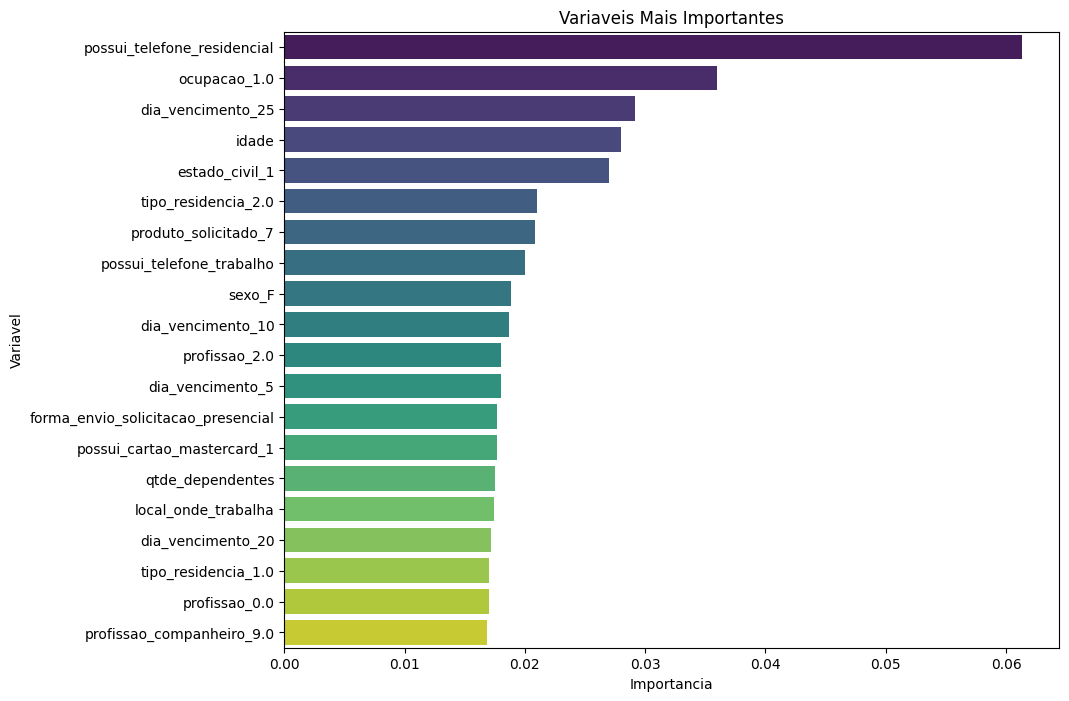


Variaveis menos importantes
                      Variavel  Importancia
24              profissao_15.0          0.0
19              profissao_10.0          0.0
13           meses_no_trabalho          0.0
23              profissao_14.0          0.0
18               profissao_1.0          0.0
50   profissao_companheiro_2.0          0.0
53   profissao_companheiro_8.0          0.0
42   profissao_companheiro_1.0          0.0
45  profissao_companheiro_12.0          0.0
28               profissao_3.0          0.0
25              profissao_16.0          0.0
26              profissao_17.0          0.0
29               profissao_4.0          0.0
38                ocupacao_3.0          0.0
30               profissao_5.0          0.0
31               profissao_6.0          0.0
51   profissao_companheiro_3.0          0.0
52   profissao_companheiro_6.0          0.0
49  profissao_companheiro_17.0          0.0
46  profissao_companheiro_13.0          0.0
47  profissao_companheiro_14.0          0.0
48 

In [6]:
importancias = xgb_model.feature_importances_
nomes_colunas = X.columns

df_importancia = pd.DataFrame({
    'Variavel': nomes_colunas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variavel', data=df_importancia.head(20), palette='viridis')
plt.title('Variaveis Mais Importantes')
plt.show()

print("\nVariaveis menos importantes")
print(df_importancia[df_importancia['Importancia'] < 0.001])


RESULTADOS OTIMIZADOS
Acuracia: 0.6020
ROC-AUC:  0.6425
Relatorio Detalhado:
              precision    recall  f1-score   support

           0       0.61      0.57      0.59      3000
           1       0.60      0.63      0.61      3000

    accuracy                           0.60      6000
   macro avg       0.60      0.60      0.60      6000
weighted avg       0.60      0.60      0.60      6000



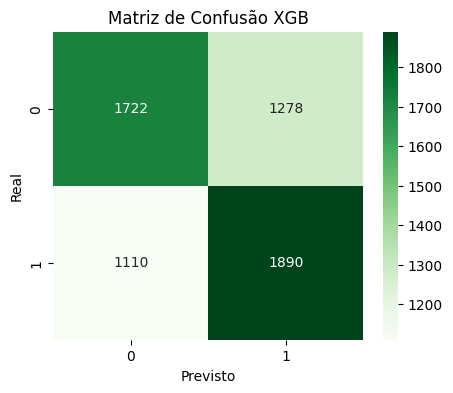

In [7]:
colunas_inuteis = df_importancia[df_importancia['Importancia'] == 0]['Variavel'].tolist()
X_otimizado = X.drop(columns=colunas_inuteis)
df_teste_otimizado = df_teste_final.drop(columns=colunas_inuteis)

X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_otimizado, y, test_size=0.3, random_state=42, stratify=y
)

xgb_validador = XGBClassifier(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=10,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    early_stopping_rounds=50)

# Treina apenas em 70% para testar nos outros 30%
xgb_validador.fit(
    X_train_opt, y_train_opt,
    eval_set=[(X_val_opt, y_val_opt)],
    verbose=False
)

y_pred_opt = xgb_validador.predict(X_val_opt)

y_proba_opt = xgb_validador.predict_proba(X_val_opt)[:, 1]

acc = accuracy_score(y_val_opt, y_pred_opt)
auc = roc_auc_score(y_val_opt, y_proba_opt)

print("\nRESULTADOS OTIMIZADOS")
print(f"Acuracia: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}")
print("Relatorio Detalhado:")
print(classification_report(y_val_opt, y_pred_opt))

# Matriz de Confusao
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_val_opt, y_pred_opt), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão XGB')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

AUC Final: 0.6425
Melhor Ponto de Corte (Threshold): 0.4632


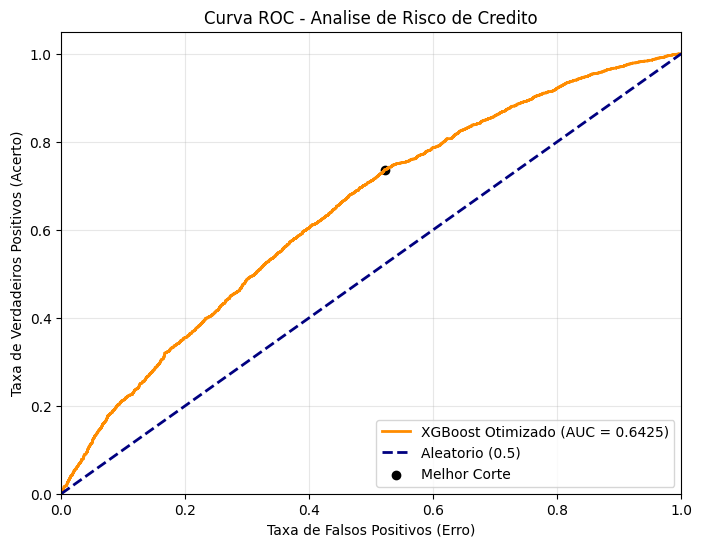

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
fpr, tpr, thresholds = roc_curve(y_val_opt, y_proba_opt)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"AUC Final: {auc:.4f}")
print(f"Melhor Ponto de Corte (Threshold): {optimal_threshold:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost Otimizado (AUC = {auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio (0.5)')

# Marcar o ponto otimo
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='black', label='Melhor Corte')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (Erro)')
plt.ylabel('Taxa de Verdadeiros Positivos (Acerto)')
plt.title('Curva ROC - Analise de Risco de Credito')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

previsoes_proba_teste = xgb_validador.predict_proba(df_teste_otimizado)[:, 1]
previsoes_leve = (previsoes_proba_teste >= optimal_threshold).astype(int)

if 'id_solicitante' in df_teste_original.columns:
    coluna_id = df_teste_original['id_solicitante']
else:
    coluna_id = df_teste_original.index

submissao = pd.DataFrame({
    'id_solicitante': coluna_id,
    'inadimplente': previsoes_leve
})

caminho_saida = 'resultado_xgboost.csv'
submissao.to_csv(caminho_saida, index=False)

files.download(caminho_saida)

xgb_final_full = XGBClassifier(
    n_estimators = xgb_validador.best_iteration + 50,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=10,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

xgb_final_full.fit(X_otimizado, y)

previsoes_proba_final = xgb_final_full.predict_proba(df_teste_otimizado)[:, 1]

previsoes_finais_otimizadas = (previsoes_proba_final >= optimal_threshold).astype(int)

submissao_final = pd.DataFrame({
    'id_solicitante': coluna_id,
    'inadimplente': previsoes_finais_otimizadas
})

caminho_final = 'resultado_xgboost_full_otimizado.csv'
submissao_final.to_csv(caminho_final, index=False)
files.download(caminho_final)

Metricas com Corte Otimizado (0.4632) ---
Precisao: 0.5854
Recall: 0.7367
F1-Score: 0.6524
Acuracia: 0.6075

Matriz de Confusao Otimizada:
[[1435 1565]
 [ 790 2210]]


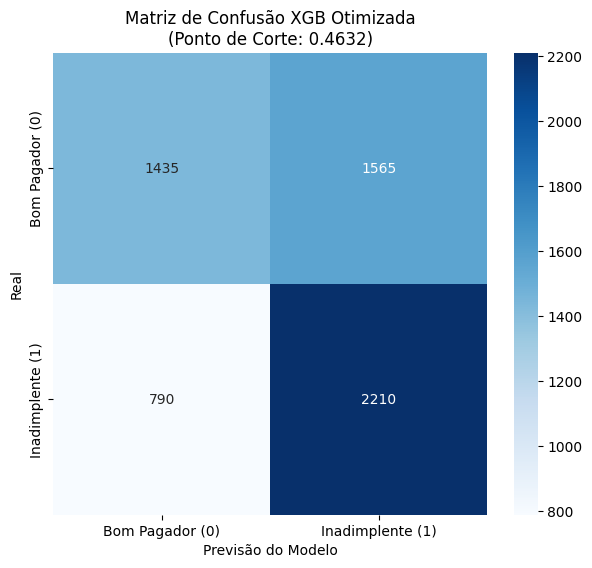

In [9]:
y_proba_val = xgb_validador.predict_proba(X_val_opt)[:, 1]

corte = optimal_threshold
y_pred_otimizado = (y_proba_val >= corte).astype(int)

precisao = precision_score(y_val_opt, y_pred_otimizado)
recall = recall_score(y_val_opt, y_pred_otimizado)
f1 = f1_score(y_val_opt, y_pred_otimizado)
acuracia = accuracy_score(y_val_opt, y_pred_otimizado)

print(f"Metricas com Corte Otimizado ({corte:.4f}) ---")
print(f"Precisao: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Acuracia: {acuracia:.4f}")

# Matriz de Confusao
cm = confusion_matrix(y_val_opt, y_pred_otimizado)
print("\nMatriz de Confusao Otimizada:")
print(cm)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bom Pagador (0)', 'Inadimplente (1)'],
            yticklabels=['Bom Pagador (0)', 'Inadimplente (1)'])

plt.ylabel('Real')
plt.xlabel('Previsão do Modelo')
plt.title(f'Matriz de Confusão XGB Otimizada\n(Ponto de Corte: {corte:.4f})')
plt.show()